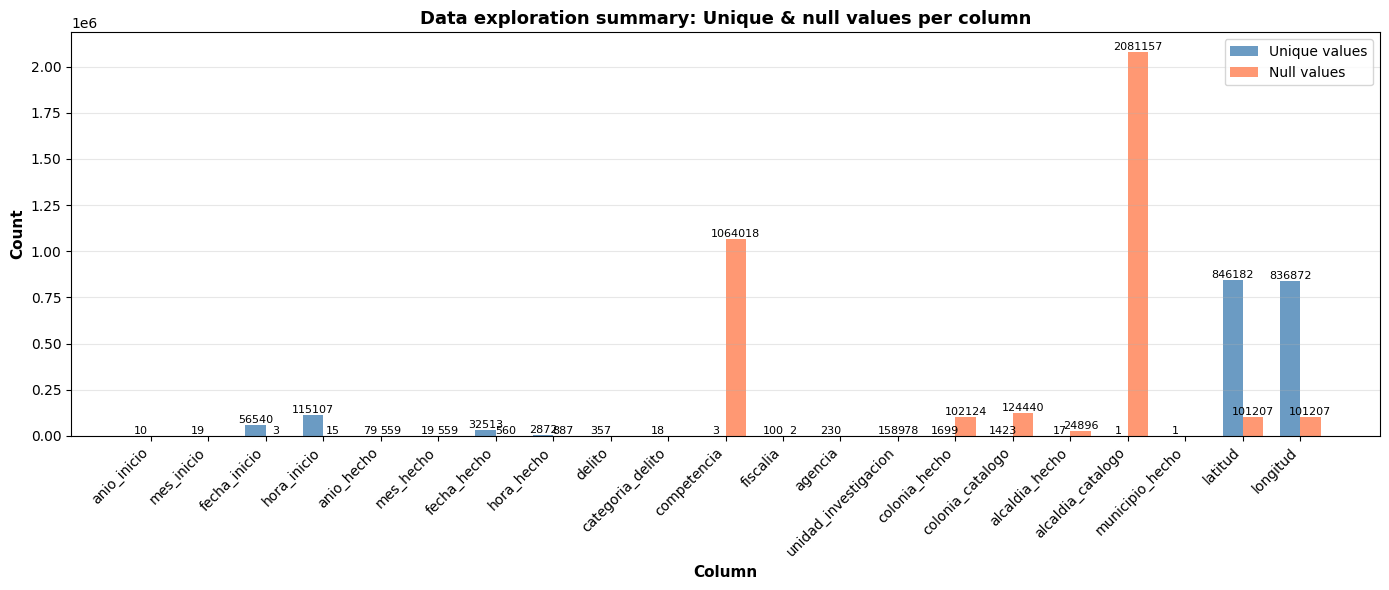

Data exploration summary

anio_inicio               | Unique:     10 | Nulls:      0

mes_inicio                | Unique:     19 | Nulls:      0

fecha_inicio              | Unique:  56540 | Nulls:      3

hora_inicio               | Unique: 115107 | Nulls:     15

anio_hecho                | Unique:     79 | Nulls:    559

mes_hecho                 | Unique:     19 | Nulls:    559

fecha_hecho               | Unique:  32513 | Nulls:    560

hora_hecho                | Unique:   2872 | Nulls:    887

delito                    | Unique:    357 | Nulls:      0

categoria_delito          | Unique:     18 | Nulls:      0

competencia               | Unique:      3 | Nulls: 1064018

fiscalia                  | Unique:    100 | Nulls:      2

agencia                   | Unique:    230 | Nulls:      0

unidad_investigacion      | Unique:    158 | Nulls:    978

colonia_hecho             | Unique:   1699 | Nulls: 102124

colonia_catalogo          | Unique:   1423 | Nulls: 124440

alcaldia_hech

In [ ]:
# Visualize summary of unique values per column
fig, ax = plt.subplots(figsize=(14, 6))

columns_names = list(unique_summary.keys())
unique_counts = [unique_summary[col]['unique_count'] for col in columns_names]
null_counts = [unique_summary[col]['null_count'] for col in columns_names]

x_pos = np.arange(len(columns_names))
width = 0.35

bars1 = ax.bar(x_pos - width/2, unique_counts, width, label='Unique values', color='steelblue', alpha=0.8)
bars2 = ax.bar(x_pos + width/2, null_counts, width, label='Null values', color='coral', alpha=0.8)

ax.set_xlabel('Column', fontsize=11, fontweight='bold')
ax.set_ylabel('Count', fontsize=11, fontweight='bold')
ax.set_title('Data exploration summary: Unique & null values per column', fontsize=13, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(columns_names, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{int(height)}',
                   ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Print summary statistics
print("Data exploration summary")
for col in columns_names:
    info = unique_summary[col]
    print(f"\n{col:25} | Unique: {info['unique_count']:6} | Nulls: {info['null_count']:6}")


Reviewing the values and the json, we can consider that column alcaldia_catalogo can be discarded since the only value is CDMX and the rest is null but still corresponding to mexico city. Something similar happens to municipio_hecho which only contains the same value but since the dataset corresponds to the same state, is useless.
Columns like months require normalization and be stablished all to spanish.
unidad_investigacion will not be considered for this since corresponds to the unit in charge of processing the crime but we are not considering that as part of the data

## Data cleaning

In [ ]:
text_cols = data.select_dtypes(include=["object", "str"]).columns
for col in text_cols:
    data[col] = (
        data[col]
        .astype(str)
        .str.replace("\n", " ", regex=False)
        .str.replace("\r", " ", regex=False)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )
print("Saltos de línea limpiados en columnas de texto")

# HASTA AQUI LLEGA LUISMI CON EL EDA

# LUISMI FASE 5.1

In [ ]:
"""
=============================================================================
Urban Crime CDMX — Etapa 5.1: Armonización semántica de categorías delictivas
=============================================================================
Enfoque híbrido:
  1. Normalización textual (duplicados ortográficos)
  2. Macro-categorías definidas con criterio criminológico + reglas semánticas
  3. Categorías limpias por similitud TF-IDF + coseno para casos ambiguos
  4. Reporte de asignaciones para validación manual

Output: CSV de mapeo (delito_original → delito_limpio → macro_categoria)
        + dataset con columnas nuevas aplicadas
=============================================================================
"""

import pandas as pd
import numpy as np
import re
import unicodedata
from collections import OrderedDict
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# ============================================================================
# PASO 0: Cargar datos
# ============================================================================
df = pd.read_csv("carpetasFGJ_fase1.csv")
delitos_unicos = df['delito'].value_counts().reset_index()
delitos_unicos.columns = ['delito_original', 'conteo']
print(f"Categorías únicas: {len(delitos_unicos)}")
print(f"Registros totales: {len(df):,}")

# ============================================================================
# PASO 1: Normalización textual
# ============================================================================
def normalizar_texto(texto):
    """Quita acentos, homologa espacios, mayúsculas, caracteres especiales."""
    if pd.isna(texto):
        return ""
    t = str(texto).upper().strip()
    # Quitar acentos
    t = unicodedata.normalize('NFD', t)
    t = ''.join(c for c in t if unicodedata.category(c) != 'Mn')
    # Homologar espacios múltiples
    t = re.sub(r'\s+', ' ', t)
    # Quitar paréntesis vacíos o con solo espacios
    t = re.sub(r'\(\s*\)', '', t)
    return t.strip()

delitos_unicos['delito_normalizado'] = delitos_unicos['delito_original'].apply(normalizar_texto)

# Detectar duplicados por normalización
duplicados = delitos_unicos.groupby('delito_normalizado').filter(lambda x: len(x) > 1)
if len(duplicados) > 0:
    print(f"\n{'='*80}")
    print(f"DUPLICADOS DETECTADOS POR NORMALIZACIÓN ({len(duplicados)} etiquetas):")
    print(f"{'='*80}")
    for nombre, grupo in duplicados.groupby('delito_normalizado'):
        total = grupo['conteo'].sum()
        print(f"\n  → '{nombre}' (total combinado: {total:,})")
        for _, row in grupo.iterrows():
            print(f"      '{row['delito_original']}' → {row['conteo']:,}")
else:
    print("\nNo se detectaron duplicados por normalización.")

# ============================================================================
# PASO 2: Definir macro-categorías con reglas semánticas
# ============================================================================
# Orden importa: las reglas se evalúan de arriba a abajo, primera que matchea gana.
# Cada regla: (nombre_macro, función_booleana sobre el texto normalizado)

def definir_reglas_macro():
    """
    Reglas ordenadas por especificidad (más específicas primero).
    Cada tupla: (macro_categoria, función_test)
    """
    reglas = OrderedDict()
    
    # --- FEMINICIDIO (antes de HOMICIDIO para que no lo capture) ---
    reglas['FEMINICIDIO'] = lambda t: 'FEMINICIDIO' in t
    
    # --- HOMICIDIO ---
    reglas['HOMICIDIO'] = lambda t: (
        'HOMICIDIO' in t and 'FEMINICIDIO' not in t
    )
    
    # --- PÉRDIDA DE LA VIDA (no homicidio: suicidio, enfermedad, accidente) ---
    reglas['PERDIDA DE LA VIDA'] = lambda t: 'PERDIDA DE LA VIDA' in t
    
    # --- TENTATIVA DE HOMICIDIO / FEMINICIDIO (ya capturadas arriba) ---
    # Se capturan por las reglas de FEMINICIDIO y HOMICIDIO que incluyen TENTATIVA
    
    # --- DELITOS SEXUALES ---
    reglas['DELITOS SEXUALES'] = lambda t: any(k in t for k in [
        'VIOLACION', 'ABUSO SEXUAL', 'ACOSO SEXUAL', 'ESTUPRO',
        'CONTRA LA INTIMIDAD SEXUAL', 'INTIMIDAD SEXUAL',
        'PORNOGRAFIA', 'LENOCINIO', 'CORRUPCION DE MENORES',
        'CORRUPCION DE PERSONAS MENORES', 'TRATA DE PERSONAS',
        'PELIGRO DE CONTAGIO', 'CONTAGIO VENEREO',
        'VIOLACION DE LA INTIMIDAD', 'INCESTO'
    ]) and 'VEHICULO' not in t  # excluir "VIOLACION Y ROBO DE VEHICULO"
    
    # --- VIOLENCIA FAMILIAR ---
    reglas['VIOLENCIA FAMILIAR'] = lambda t: 'VIOLENCIA FAMILIAR' in t
    
    # --- LESIONES CULPOSAS (tránsito, caída, accidente — sin intención) ---
    reglas['LESIONES CULPOSAS'] = lambda t: (
        'LESIONES CULPOSAS' in t or 'LESIONES CULPOSAS' in t
    )
    
    # --- LESIONES INTENCIONALES ---
    reglas['LESIONES INTENCIONALES'] = lambda t: (
        ('LESIONES INTENCIONALES' in t or 'LESIONES DOLOSAS' in t)
        and 'VEHICULO' not in t  # excluir compuestos con robo
    )
    
    # --- ROBO CON VIOLENCIA ---
    reglas['ROBO CON VIOLENCIA'] = lambda t: (
        ('ROBO' in t and ('CON VIOLENCIA' in t or 'C/V' in t))
        or ('ROBO' in t and 'ASALTO' in t)
    )
    
    # --- ROBO SIN VIOLENCIA ---
    reglas['ROBO SIN VIOLENCIA'] = lambda t: (
        'ROBO' in t and 'CON VIOLENCIA' not in t and 'C/V' not in t
        and 'ASALTO' not in t
        # Incluye: S/V, SIN VIOLENCIA, FARDEROS, y robos sin especificar
    )
    
    # --- FRAUDE Y DELITOS PATRIMONIALES ---
    reglas['FRAUDE Y DELITOS PATRIMONIALES'] = lambda t: any(k in t for k in [
        'FRAUDE', 'ABUSO DE CONFIANZA', 'USURPACION DE IDENTIDAD',
        'DESPOJO', 'EXTORSION', 'TENTATIVA DE EXTORSION',
        'COBRANZA ILEGITIMA', 'TENTATIVA DE FRAUDE',
        'INSOLVENCIA', 'OPERACIONES CON RECURSOS'
    ])
    
    # --- FALSIFICACIÓN Y DOCUMENTOS ---
    reglas['FALSIFICACION Y DOCUMENTOS'] = lambda t: any(k in t for k in [
        'FALSIFICACION', 'FALSEDAD', 'USO DE DOCUMENTO FALSO',
        'USO INDEBIDO DE DOCUMENTO', 'PRODUCCION, IMPRESION',
        'TITULO', 'PORTADOR', 'CREDITO PUBLICO',
        'ALTERACION', 'SELLOS, MARCAS'
    ]) and 'ROBO' not in t
    
    # --- DAÑO EN PROPIEDAD ---
    reglas['DANO EN PROPIEDAD'] = lambda t: 'DANO EN PROPIEDAD' in t
    
    # --- AMENAZAS ---
    reglas['AMENAZAS'] = lambda t: (
        'AMENAZAS' in t or 'INTIMIDACION' in t
    ) and 'ROBO' not in t
    
    # --- NARCOMENUDEO ---
    reglas['NARCOMENUDEO'] = lambda t: (
        'NARCOMENUDEO' in t or 'DELITOS CONTRA LA SALUD' in t
    )
    
    # --- PRIVACIÓN DE LIBERTAD Y SECUESTRO ---
    reglas['PRIVACION DE LIBERTAD'] = lambda t: any(k in t for k in [
        'PRIVACION DE LA LIBERTAD', 'PRIVACION ILEGAL',
        'PRIV. ILEGAL', 'SECUESTRO', 'PLAGIO',
        'DESAPARICION FORZADA'
    ]) and 'ROBO' not in t and 'VEHICULO' not in t
    
    # --- DELITOS CONTRA MENORES E INCAPACES ---
    reglas['DELITOS CONTRA MENORES'] = lambda t: any(k in t for k in [
        'SUSTRACCION DE MENORES', 'SUSTRACCION DE MENORES',
        'RETENCION DE MENORES', 'RETENCION O SUSTRACCION',
        'ENTREGA ILEGITIMA', 'EXPOSICION DE MENORES',
        'TRAFICO DE INFANTES', 'ROBO DE INFANTE',
        'EXPLOTACION DE MENOR', 'EXPLOTACION LABORAL DE MENORES',
        'ABANDONO DE PERSONA', 'CONTRA EL CUMPLIMIENTO DE LA OBLIGACION ALIMENTARIA',
        'PORNOGRAFIA INFANTIL'
    ])
    
    # --- DELITOS DE SERVIDORES PÚBLICOS ---
    reglas['DELITOS DE SERVIDORES PUBLICOS'] = lambda t: any(k in t for k in [
        'ABUSO DE AUTORIDAD', 'EJERCICIO INDEBIDO DEL SERVIDOR',
        'EJERCICIO ILEGAL Y ABANDONO DEL SERVICIO',
        'PECULADO', 'COHECHO', 'CONCUSION',
        'ENRIQUECIMIENTO ILICITO', 'TRAFICO DE INFLUENCIA',
        'COALICION DE SERVIDORES', 'COACCION DE SERVIDORES',
        'EJERCICIO ABUSIVO DE FUNCIONES', 'NEGACION DEL SERVICIO',
        'USO INDEBIDO DE ATRIBUCIONES', 'TORTURA',
        'CONTRA FUNCIONARIOS PUBLICOS',
        'USURPACION DE FUNCIONES PUBLICAS'
    ])
    
    # --- DELITOS AMBIENTALES Y URBANOS ---
    reglas['DELITOS AMBIENTALES'] = lambda t: any(k in t for k in [
        'AMBIENTALES', 'TALA', 'CAMBIO DE USO DE SUELO',
        'CONTAMINACION', 'RESIDUOS', 'DANO SUELO',
        'REGULACION URBANA', 'GESTION AMBIENTAL'
    ])
    
    # --- ARMAS ---
    reglas['PORTACION DE ARMAS'] = lambda t: any(k in t for k in [
        'PORTACION DE ARMA', 'PORTACION ARMA',
        'PORTACION, FABRICACION', 'DISPAROS DE ARMA',
        'LEY FEDERAL DE ARMAS', 'CONTRA LA LEY GENERAL DE EXPLOSIVOS'
    ]) and 'ROBO' not in t and 'HOMICIDIO' not in t and 'LESIONES' not in t
    
    # --- DELITOS ELECTORALES ---
    reglas['DELITOS ELECTORALES'] = lambda t: 'ELECTORALES' in t
    
    # --- DISCRIMINACIÓN Y DERECHOS HUMANOS ---
    reglas['DISCRIMINACION Y DERECHOS HUMANOS'] = lambda t: any(k in t for k in [
        'DISCRIMINACION', 'DDH ', 'DDH_', 'DERECHOS HUMANOS',
        'VIOLACION A LOS DERECHOS HUMANOS'
    ])
    
    # --- DELITOS CONTRA LA ADMINISTRACIÓN DE JUSTICIA ---
    reglas['DELITOS CONTRA ADMIN DE JUSTICIA'] = lambda t: any(k in t for k in [
        'ADMINISTRACION DE JUSTICIA', 'ENCUBRIMIENTO',
        'DESOBEDIENCIA', 'DESOBEDENCIA', 'RESISTENCIA DE PARTICULARES',
        'EVASION DE PRESOS', 'QUEBRANTAMIENTO',
        'DESACATO', 'MOTIN'
    ])
    
    # --- DELITOS PROFESIONALES Y LEGALES ---
    reglas['DELITOS PROFESIONALES'] = lambda t: any(k in t for k in [
        'RESPONSABILIDAD PROFESIONAL', 'DELITOS DE ABOGADOS',
        'USURPACION DE PROFESION', 'EJERCICIO INDEBIDO DEL PROPIO',
        'REVELACION DE SECRETOS', 'VARIACION DE NOMBRE',
        'VIOLACION DE CORRESPONDENCIA',
        'FABRICACION, COMERCIALIZACION Y USO INDEBIDO DE INSIGNIAS'
    ])
    
    # --- DENUNCIA DE HECHOS (categoría especial) ---
    reglas['DENUNCIA DE HECHOS'] = lambda t: 'DENUNCIA DE HECHOS' in t
    
    # --- PERSONAS EXTRAVIADAS ---
    reglas['PERSONAS EXTRAVIADAS'] = lambda t: 'PERSONAS EXTRAVIADAS' in t
    
    # --- ABORTO ---
    reglas['OTROS DELITOS'] = lambda t: any(k in t for k in [
        'ABORTO', 'BIGAMIA', 'CONTRA EL ESTADO CIVIL',
        'PROCREACION ASISTIDA', 'PANDILLA', 'ASOCIACION DELICTUOSA',
        'ATAQUES A LA PAZ', 'OPOSICION A', 'SABOTAJE',
        'PROVOCACION O APOLOGIA', 'CALUMNIAS', 'DIFAMACION',
        'INJURIAS', 'ULTRAJES', 'OTROS DELITOS', 'OTROS CULPOSOS',
        'EXHORTOS', 'UTILIZACION INDEBIDA', 'CONTRA LA LEY FEDERAL DE POBLACION',
        'ATAQUE A LAS VIAS', 'ALLANAMIENTO', 'OMISION DE AUXILIO',
        'MALTRATO ANIMAL'
    ])
    
    return reglas

reglas = definir_reglas_macro()
print(f"\nMacro-categorías definidas: {len(reglas)}")
for nombre in reglas:
    print(f"  • {nombre}")

# ============================================================================
# PASO 3: Aplicar reglas + detectar no asignados
# ============================================================================
def asignar_macro(texto_normalizado, reglas):
    """Aplica reglas en orden. Retorna (macro_categoria, metodo)."""
    for nombre, test in reglas.items():
        try:
            if test(texto_normalizado):
                return nombre, 'regla'
        except:
            continue
    return None, None

# Aplicar a cada delito único
asignaciones = []
for _, row in delitos_unicos.iterrows():
    macro, metodo = asignar_macro(row['delito_normalizado'], reglas)
    asignaciones.append({
        'delito_original': row['delito_original'],
        'delito_normalizado': row['delito_normalizado'],
        'conteo': row['conteo'],
        'macro_categoria': macro,
        'metodo_asignacion': metodo
    })

df_mapeo = pd.DataFrame(asignaciones)

# Estadísticas de asignación
asignados = df_mapeo['macro_categoria'].notna().sum()
no_asignados = df_mapeo['macro_categoria'].isna().sum()
print(f"\n{'='*80}")
print(f"RESULTADO DE ASIGNACIÓN POR REGLAS:")
print(f"{'='*80}")
print(f"  Asignados:    {asignados} de {len(df_mapeo)} ({asignados/len(df_mapeo)*100:.1f}%)")
print(f"  No asignados: {no_asignados} de {len(df_mapeo)} ({no_asignados/len(df_mapeo)*100:.1f}%)")

# Mostrar no asignados
if no_asignados > 0:
    print(f"\n  CATEGORÍAS NO ASIGNADAS ({no_asignados}):")
    no_asig = df_mapeo[df_mapeo['macro_categoria'].isna()].sort_values('conteo', ascending=False)
    for _, row in no_asig.iterrows():
        print(f"    {row['conteo']:>8,}  {row['delito_original']}")
